# CC 311 Econometrics — Unit 5 — Lecture 2.1
## Practical ARIMA Forecasting: Box–Jenkins Methodology
### US GDP example

**Identification → Estimation → Diagnostic checking → Train/Test forecasting → Forecast evaluation → Final forecasting**

Key objective: although differencing is used to obtain stationarity, the **final forecast is reported on the original GDP level**, not merely as a forecast of the differenced series.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from pandas_datareader import data as web
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## 1. Load US GDP from FRED

We are using quarterly US GDP. The original GDP series remains the object we ultimately want to forecast.

In [ ]:
start = datetime.datetime(1947, 1, 1)
end = datetime.datetime.today()

gdp = web.DataReader("GDP", "fred", start, end).dropna()

print(gdp.head())
print(gdp.tail())
print("\nObservations:", len(gdp))

                GDP
DATE               
1947-01-01  243.164
1947-04-01  245.968
1947-07-01  249.585
1947-10-01  259.745
1948-01-01  265.742
                  GDP
DATE                 
2025-04-01  30630.174
2025-07-01  31180.493
2025-10-01  31462.523
2026-01-01  31906.274
2026-04-01  32563.030

Observations: 318


In [ ]:
gdp

,GDP
DATE,
1947-01-01,243.164
1947-04-01,245.968
1947-07-01,249.585
1947-10-01,259.745
1948-01-01,265.742
...,...
2025-04-01,30630.174
2025-07-01,31180.493
2025-10-01,31462.523


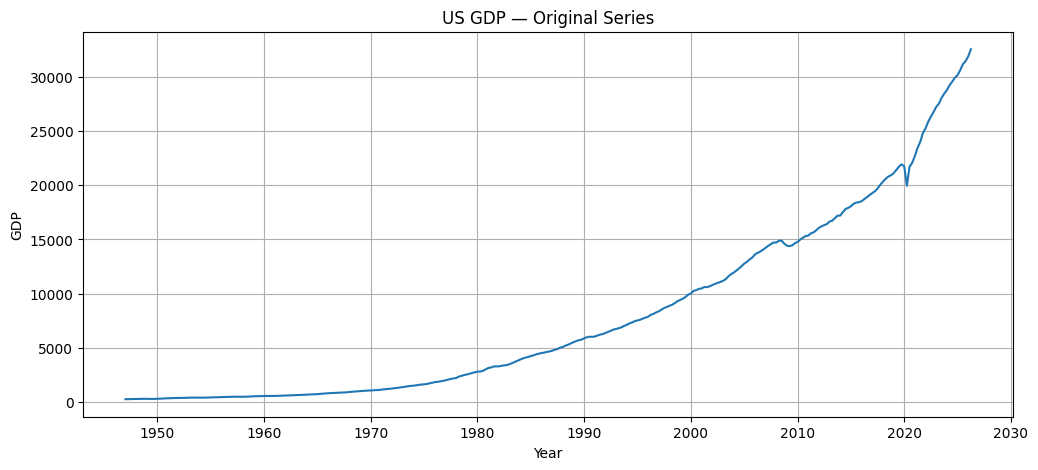

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(gdp.index, gdp["GDP"])
plt.title("US GDP — Original Series")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.show()

# BOX–JENKINS STEP 1: IDENTIFICATION

First check whether GDP in levels is stationary. If necessary, difference the series and then use ACF/PACF to guide the AR and MA orders.

In [ ]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF Test: {name}")
    print("-"*50)
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"5% critical   : {result[4]['5%']:.4f}")
    print("Conclusion:", "stationary" if result[1] < 0.05 else "non-stationary")
    print()

adf_test(gdp["GDP"], "GDP in levels")

ADF Test: GDP in levels
--------------------------------------------------
ADF statistic : 10.2086
p-value       : 1.0000
5% critical   : -2.8707
Conclusion: non-stationary



/tmp/ipykernel_2964/2180968669.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag="AIC")


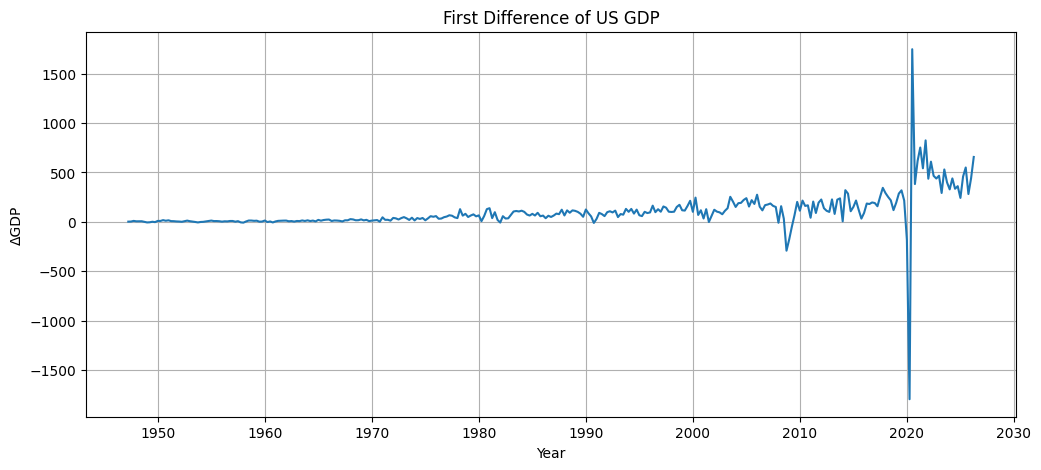

ADF Test: First difference of GDP
--------------------------------------------------
ADF statistic : -3.2832
p-value       : 0.0156
5% critical   : -2.8708
Conclusion: stationary



/tmp/ipykernel_2964/2180968669.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag="AIC")


In [ ]:
gdp["GDP_diff"] = gdp["GDP"].diff()

plt.figure(figsize=(12,5))
plt.plot(gdp.index, gdp["GDP_diff"])
plt.title("First Difference of US GDP")
plt.xlabel("Year")
plt.ylabel("ΔGDP")
plt.show()

adf_test(gdp["GDP_diff"], "First difference of GDP")

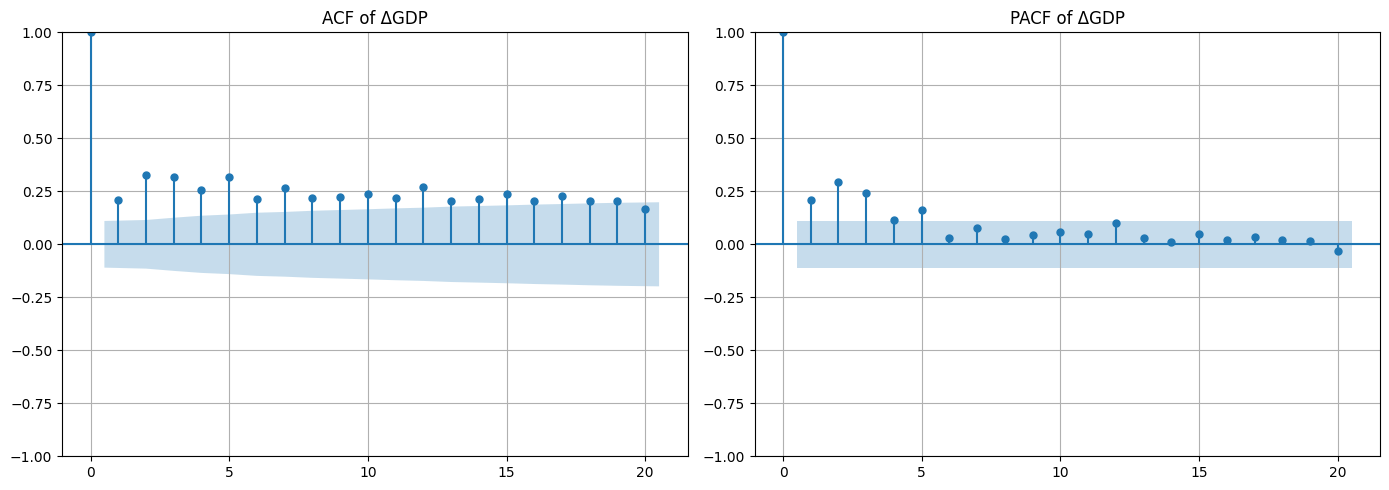

In [ ]:
diff_series = gdp["GDP_diff"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_acf(diff_series, lags=20, ax=axes[0])
axes[0].set_title("ACF of ΔGDP")
plot_pacf(diff_series, lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of ΔGDP")
plt.tight_layout()
plt.show()

# BOX–JENKINS STEP 2: ESTIMATION

Because first differencing was required, use \(d=1\). Compare a small grid of candidate ARIMA\((p,1,q)\) models using AIC and BIC.

In [ ]:
candidate_models = []

for p in range(5):
    for q in range(5):
        try:
            fitted = ARIMA(gdp["GDP"], order=(p,1,q)).fit()
            candidate_models.append({
                "p": p, "d": 1, "q": q,
                "AIC": fitted.aic, "BIC": fitted.bic
            })
        except Exception:
            pass

model_table = pd.DataFrame(candidate_models).sort_values("AIC")
display(model_table)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be use

,p,d,q,AIC,BIC
11,2,1,1,4160.927265,4175.962872
7,1,1,2,4161.388531,4176.424138
8,1,1,3,4162.341314,4181.135822
16,3,1,1,4162.720655,4181.515164
12,2,1,2,4162.824282,4181.618791
17,3,1,2,4162.891703,4185.445113
21,4,1,1,4163.566927,4186.120338
13,2,1,3,4163.691904,4186.245315
9,1,1,4,4163.783595,4186.337005
18,3,1,3,4163.847595,4190.159907


In [ ]:
best = model_table.iloc[0]
best_p, best_d, best_q = int(best.p), int(best.d), int(best.q)

print(f"Selected model: ARIMA({best_p}, {best_d}, {best_q})")
print(f"AIC = {best.AIC:.2f}")
print(f"BIC = {best.BIC:.2f}")

Selected model: ARIMA(2, 1, 1)
AIC = 4160.93
BIC = 4175.96


In [ ]:
model_fit = ARIMA(
    gdp["GDP"],
    order=(best_p, best_d, best_q)
).fit()

print(model_fit.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


                               SARIMAX Results                                
Dep. Variable:                    GDP   No. Observations:                  318
Model:                 ARIMA(2, 1, 1)   Log Likelihood               -2076.464
Date:                Thu, 08 Oct 2026   AIC                           4160.927
Time:                        19:04:08   BIC                           4175.963
Sample:                    01-01-1947   HQIC                          4166.933
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8563      0.024     36.413      0.000       0.810       0.902
ar.L2          0.1417      0.021      6.668      0.000       0.100       0.183
ma.L1         -0.8963      0.022    -40.224      0.0

# BOX–JENKINS STEP 3: DIAGNOSTIC CHECKING

A good fitted model should leave residuals that are approximately white noise. Examine the residual series, ACF/PACF and Ljung–Box test.

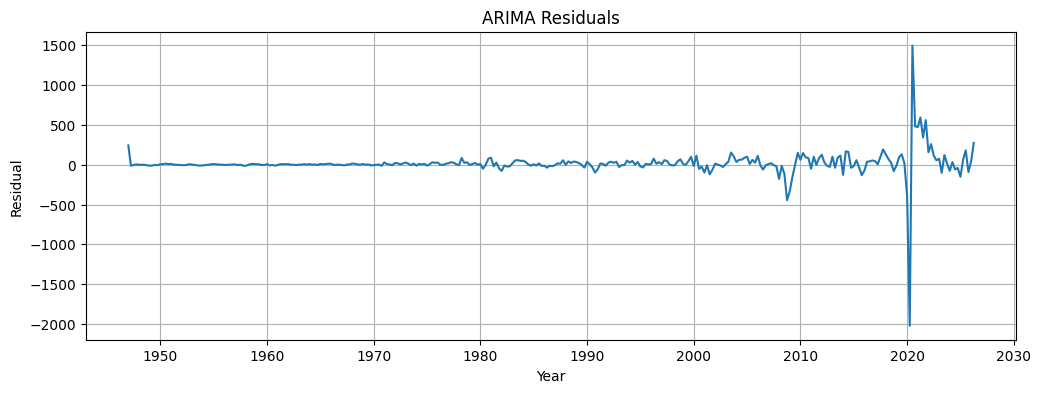

In [ ]:
residuals = model_fit.resid

plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("ARIMA Residuals")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.show()

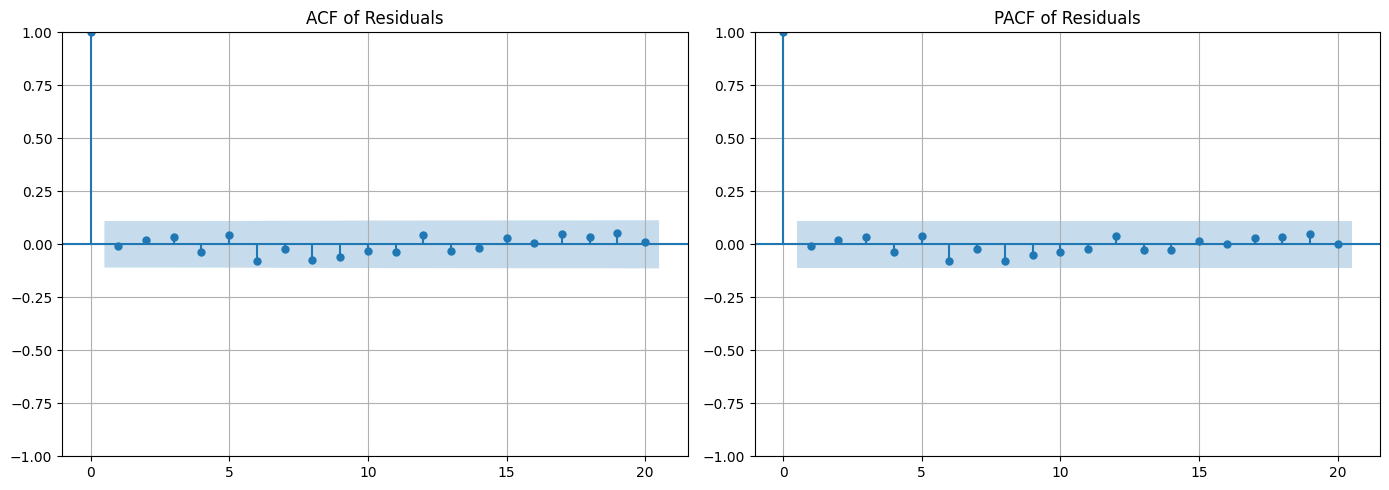

,lb_stat,lb_pvalue
10,7.196875,0.706737
20,11.240518,0.939745


In [ ]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
plot_acf(residuals.dropna(), lags=20, ax=axes[0])
axes[0].set_title("ACF of Residuals")
plot_pacf(residuals.dropna(), lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF of Residuals")
plt.tight_layout()
plt.show()

display(acorr_ljungbox(residuals.dropna(), lags=[10,20], return_df=True))

# BOX–JENKINS STEP 4: TRAIN / TEST FORECASTING

Split the **original GDP series** into training and test samples. The ARIMA model handles differencing internally.

In [ ]:
series = gdp["GDP"].dropna()

train_size = int(len(series) * 0.80)
train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Training:", train.index[0], "to", train.index[-1])
print("Testing :", test.index[0], "to", test.index[-1])
print("Train observations:", len(train))
print("Test observations :", len(test))

Training: 1947-01-01 00:00:00 to 2010-04-01 00:00:00
Testing : 2010-07-01 00:00:00 to 2026-04-01 00:00:00
Train observations: 254
Test observations : 64


In [ ]:
train_model = ARIMA(
    train,
    order=(best_p, best_d, best_q)
).fit()

forecast_result = train_model.get_forecast(steps=len(test))
forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

forecast.index = test.index
conf_int.index = test.index

print("Forecasts are on the ORIGINAL GDP scale:")
display(forecast.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


Forecasts are on the ORIGINAL GDP scale:


,predicted_mean
DATE,
2010-07-01,15145.442663
2010-10-01,15283.906177
2011-01-01,15408.067349
2011-04-01,15524.544706
2011-07-01,15636.847281


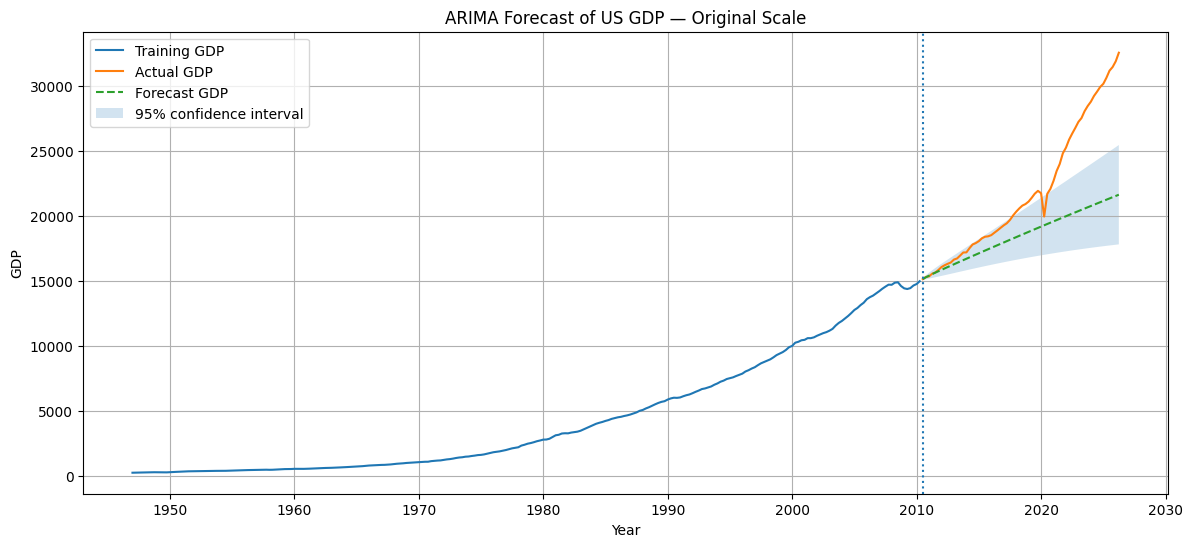

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training GDP")
plt.plot(test.index, test, label="Actual GDP")
plt.plot(forecast.index, forecast, "--", label="Forecast GDP")
plt.fill_between(
    forecast.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    alpha=0.2,
    label="95% confidence interval"
)
plt.axvline(test.index[0], linestyle=":")
plt.title("ARIMA Forecast of US GDP — Original Scale")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()

## Forecast evaluation

Because actual GDP and forecast GDP are on the same original scale, forecast errors are directly interpretable.

In [ ]:
comparison = pd.DataFrame({
    "Actual GDP": test,
    "Forecast GDP": forecast
})
comparison["Forecast Error"] = comparison["Actual GDP"] - comparison["Forecast GDP"]
display(comparison.head(10))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test-forecast)/test))*100

print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}%")

,Actual GDP,Forecast GDP,Forecast Error
DATE,,,
2010-07-01,15141.607,15145.442663,-3.835663
2010-10-01,15309.474,15283.906177,25.567823
2011-01-01,15351.448,15408.067349,-56.619349
2011-04-01,15557.539,15524.544706,32.994294
2011-07-01,15647.680,15636.847281,10.832719
2011-10-01,15842.259,15746.835599,95.423401
2012-01-01,16068.805,15855.496225,213.308775
2012-04-01,16207.115,15963.352389,243.762611
2012-07-01,16319.541,16070.681685,248.859315


MAE  = 3278.77
RMSE = 4656.87
MAPE = 12.59%


# Why don't we report only $\Delta$GDP?

If

$$\Delta GDP_t = GDP_t - GDP_{t-1}$$

the model may forecast $\widehat{\Delta GDP}_{t+1}$. But the economic question is usually **what will GDP be?**

Therefore, the change forecasts must be mapped back to the original level:

$$\widehat{GDP}_{t+1} = GDP_t + \widehat{\Delta GDP}_{t+1}$$

For multiple periods, the predicted changes are accumulated from the last observed level.

The next cells demonstrate this explicitly.


In [ ]:
# Optional teaching demonstration: forecast the differenced process

diff_train = train.diff().dropna()

diff_model = ARIMA(
    diff_train,
    order=(best_p,0,best_q)
).fit()

diff_forecast = diff_model.forecast(steps=len(test))

print("Forecast of DIFFERENCED GDP:")
display(diff_forecast.head())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


Forecast of DIFFERENCED GDP:


,predicted_mean
2010-07-01,164.223268
2010-10-01,136.951546
2011-01-01,122.410158
2011-04-01,114.597004
2011-07-01,110.340203


In [ ]:
# Reconstruct the ORIGINAL GDP level from predicted changes

manual_level_forecast = []
previous_gdp = train.iloc[-1]

for predicted_change in diff_forecast:
    predicted_gdp = previous_gdp + predicted_change
    manual_level_forecast.append(predicted_gdp)
    previous_gdp = predicted_gdp

manual_level_forecast = pd.Series(
    manual_level_forecast,
    index=test.index
)

display(pd.DataFrame({
    "Actual GDP": test,
    "Reconstructed GDP forecast": manual_level_forecast
}).head())

,Actual GDP,Reconstructed GDP forecast
DATE,,
2010-07-01,15141.607,15144.416268
2010-10-01,15309.474,15281.367814
2011-01-01,15351.448,15403.777972
2011-04-01,15557.539,15518.374976
2011-07-01,15647.680,15628.715179


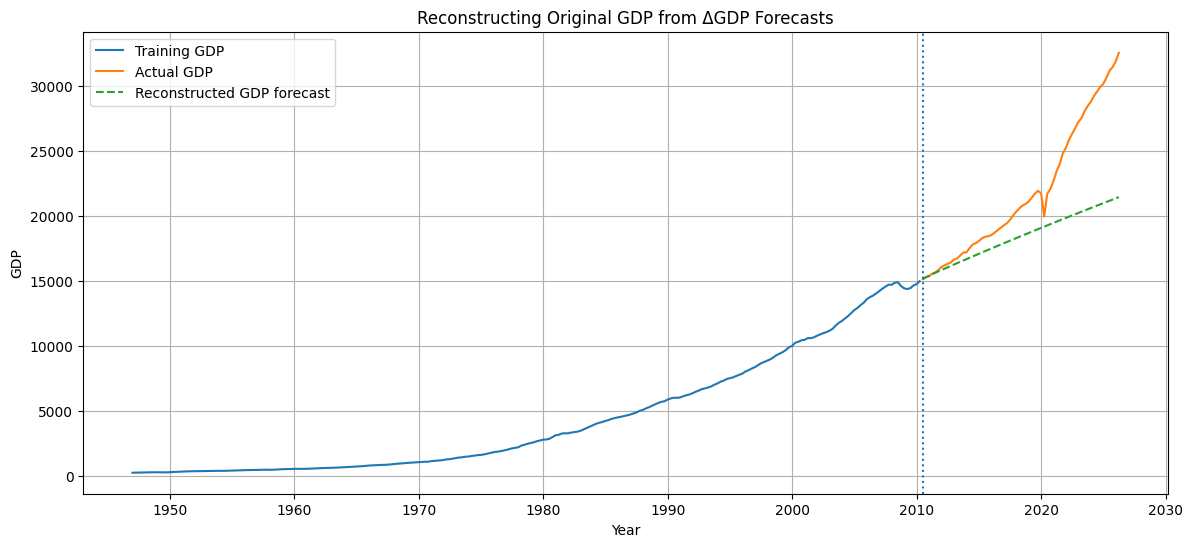

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Training GDP")
plt.plot(test.index, test, label="Actual GDP")
plt.plot(
    manual_level_forecast.index,
    manual_level_forecast,
    "--",
    label="Reconstructed GDP forecast"
)
plt.axvline(test.index[0], linestyle=":")
plt.title("Reconstructing Original GDP from ΔGDP Forecasts")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()

# Final future forecast

After train/test evaluation, refit the selected model using all observations and forecast future quarters. The output remains on the **original GDP scale**.

In [ ]:
final_model = ARIMA(
    series,
    order=(best_p,best_d,best_q)
).fit()

future_steps = 8  # next 8 quarters

future_result = final_model.get_forecast(steps=future_steps)
future_forecast = future_result.predicted_mean
future_conf = future_result.conf_int()

display(future_forecast)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params


,predicted_mean
2026-07-01,32942.110177
2026-10-01,33359.788578
2027-01-01,33771.162364
2027-04-01,34182.608237
2027-07-01,34593.222279
2027-10-01,35003.134264
2028-01-01,35412.327201
2028-04-01,35820.804933


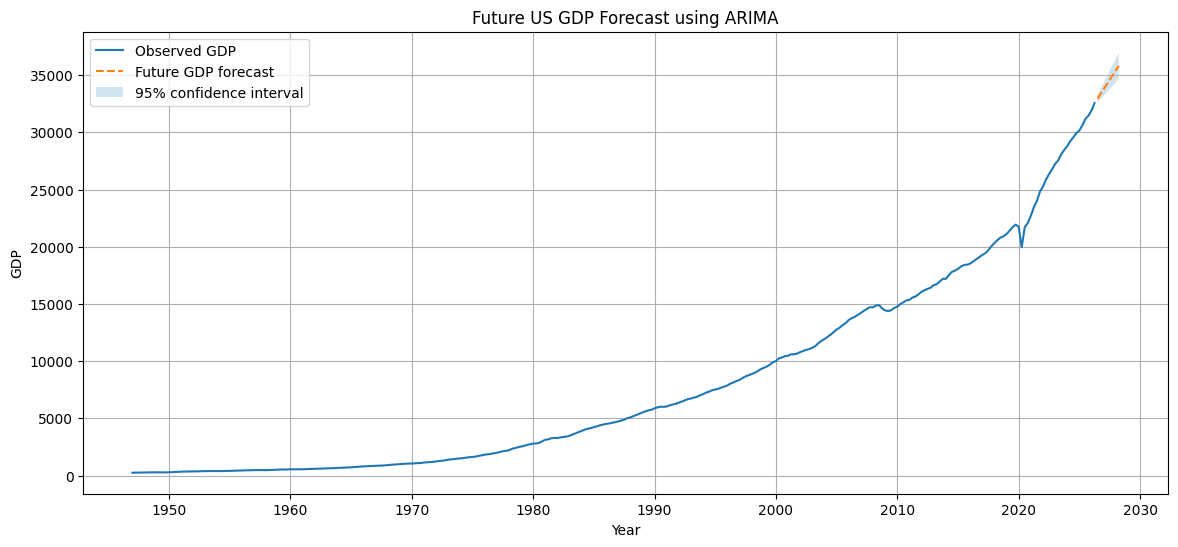

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(series.index, series, label="Observed GDP")
plt.plot(future_forecast.index, future_forecast, "--", label="Future GDP forecast")
plt.fill_between(
    future_forecast.index,
    future_conf.iloc[:,0],
    future_conf.iloc[:,1],
    alpha=0.2,
    label="95% confidence interval"
)
plt.title("Future US GDP Forecast using ARIMA")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()

# Complete Box–Jenkins workflow

1. **Identification** — plot, test stationarity, difference if needed, examine ACF/PACF.
2. **Estimation** — estimate candidate ARIMA models and compare AIC/BIC.
3. **Diagnostic checking** — examine residuals and Ljung–Box test.
4. **Forecasting** — train/test split, forecast the **original series**, evaluate accuracy.
5. **Final forecasting** — refit using all observations and generate future forecasts.

### Key message

> **Differencing is a modelling step used to handle non-stationarity. The final economic forecast should be returned to the original scale of the time series.**
